In [1]:
# standard data science packages
import pandas as pd
import numpy as np

# data viz imports
import matplotlib.pyplot as plt
import folium
import seaborn as sns

# file system imports
import os

# sklearn imports
from sklearn.model_selection import train_test_split

In [2]:
# set parameters
dataset = "361260"
seeds = range(5)
clustertype = "kmeans"
clustermodel = "linear"

In [3]:
### READ IN DATA ###
base_path = f'../cluster-results/gb/{clustertype}/{clustermodel}'
color_map = {
    'elastic_norank': 'black',
    'lime': '#71BEB7',
    'shap': 'orange',
    'maple': 'green',
    'lmdi_baseline': '#9B5DFF',
    'lmdi_sutera': 'blue',
    'random': 'gray',
    'global_elastic_norank': 'red'
}
methods_name = {
    'elastic_norank': 'LMDI+',
    'lmdi_baseline': 'LMDI',
    'lime': 'LIME',
    'shap': 'TreeSHAP',
    'maple': 'MAPLE',
    'lmdi_sutera': 'LMDI (Sutera et al.)',
    'random': 'Random',
    'global_elastic_norank': 'Global'
}

seed_means = []
seed_sds = []

# go through each of the subdirectories and read data
for seed in seeds:
    
    # check that the directory exists
    if not os.path.exists(base_path + f'/{dataset}/seed{seed}'):
        print(f"Directory {base_path}/{dataset}/seed{seed} does not exist")
        continue

    # get the data (removing the 'unnamed' column)
    mse_means = pd.read_csv(base_path + f'/{dataset}/seed{seed}/cluster_mse_mean.csv').iloc[:,1:]
    mse_sds = pd.read_csv(base_path + f'/{dataset}/seed{seed}/cluster_mse_sd.csv').iloc[:,1:]
    
    # convert sds to ses by dividing by sqrt(n)
    mse_sds = mse_sds / np.sqrt(100)
    
    # get the methods we care about
    methods = ["elastic_norank",
               'lime', 'shap',
               "global_elastic_norank", "random"]
    all_methods = []
    for method in methods:
        all_methods.append(method)
        
    # get the data for the methods we care about
    mse_means = mse_means[all_methods]
    mse_sds = mse_sds[all_methods]
    
    # append the data to the list
    seed_means.append(mse_means)
    seed_sds.append(mse_sds)
# take the average of the dataframes in the list
mean_df = pd.concat(seed_means).groupby(level=0).mean()
sd_df = pd.concat(seed_sds).groupby(level=0).mean()

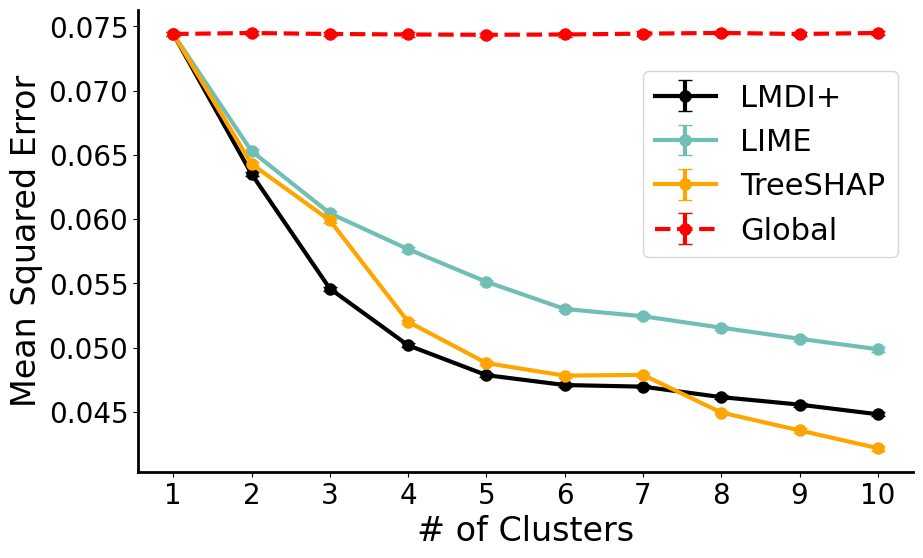

In [5]:
### PLOT CLUSTERING RESULTS ###
# The x-axis values
x_values = np.array(range(1, 11), dtype = int)

# create the plot
plt.figure(figsize=(10, 6))
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 2.0
# take off top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# set y-axis max to 0.08
# plt.ylim(bottom=0.042, top=0.077)

# plot each column as a separate line with error bars
for col in mean_df.columns:
    if methods_name[col] in ['Random', 'LMDI'] :
        continue
    if methods_name[col] == "Global":
        linestyle = "dashed"
    else:
        linestyle = "solid"
    plt.errorbar(x_values, mean_df[col], yerr=sd_df[col],
                 label=methods_name[col], color=color_map[col],
                capsize=5, fmt='o', linestyle=linestyle, linewidth=3, markersize=8)

# adding labels and title
plt.xlabel("# of Clusters", fontsize=24)
plt.ylabel("Mean Squared Error", fontsize=24)

# only put x-axis ticks on integers
plt.xticks(x_values)
# make x tick labels larger
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# locate legend on right with y = 0.07

plt.legend(loc='upper right', bbox_to_anchor=(1, 0.9), fontsize=22)

# plt.savefig("images/subgroup_error.pdf", format='pdf', bbox_inches='tight')
plt.show()